In [ ]:
import geopandas as gpd
import fiona
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'notebook'

import matplotlib.pyplot as plt

# Load the GeoPackage
fastfood = gpd.read_file("Data/fastfood_all_ohio.gpkg", layer="fastfood")

# optional: check which layers are available
fastfood_layers = fiona.listlayers("Data/fastfood_all_ohio.gpkg")
print(fastfood_layers)

['fastfood']


In [14]:
# Load the pizza file

# check all layers in the pizza file
pizza_layers = fiona.listlayers("Data/pizza_places_ohio.gpkg")
print(pizza_layers)

pizza = gpd.read_file("Data/pizza_places_ohio.gpkg", layer="pizza_places")

['pizza_places']


In [15]:
print(pizza)

     element          id   addr:city addr:housenumber addr:postcode  \
0       node   256553326  Cincinnati            11902         45249   
1       node   256553679        None             None          None   
2       node   392512318        None             None          None   
3       node   429587566        None             None          None   
4       node   497078766  Maineville             5797         45039   
...      ...         ...         ...              ...           ...   
1703     way  1442194451   Hillsboro             1461         45133   
1704     way  1442194452        None             None          None   
1705     way  1442194483   Hillsboro              589         45133   
1706     way  1442720914   Hillsboro              836         45133   
1707     way  1444608539   Mariemont             6930         45227   

     addr:state        addr:street addr:unit     amenity diet:vegan  ...  \
0            OH    Montgomery Road      None   fast_food       None  ..

In [11]:
# Count occurrences of each chain
counts = fastfood["name"].value_counts()

# Optional: convert to a DataFrame for nicer display
counts_df = counts.reset_index()
counts_df.columns = ["fastfood_chain", "count"]

print(counts_df)

                 fastfood_chain  count
0                    McDonald's    614
1                        Subway    585
2                       Wendy's    368
3                     Taco Bell    325
4                   Burger King    281
..                          ...    ...
940  Fish Sandwich French Fries      1
941             L&J’s Dairy Bar      1
942   Popeyes Louisiana Kitchen      1
943           Checkers Drive-In      1
944                 Dairy Oasis      1

[945 rows x 2 columns]


In [23]:
# check the occurances of the pizza chains
pizza_counts = pizza["name"].value_counts()

# convert to dataframe for nicer display
pizza_counts_df = pizza_counts.reset_index()
#pizza_counts_df.columns = ["fastfood_chain", "count"]

print(pizza_counts[:10])

name
Pizza Hut                174
Domino's                 161
Little Caesars            99
Papa John's               83
Marco's Pizza             83
Donatos Pizza             69
LaRosa's Pizzeria         30
Jet's Pizza               19
Gionino's Pizzeria        18
East of Chicago Pizza     18
Name: count, dtype: int64


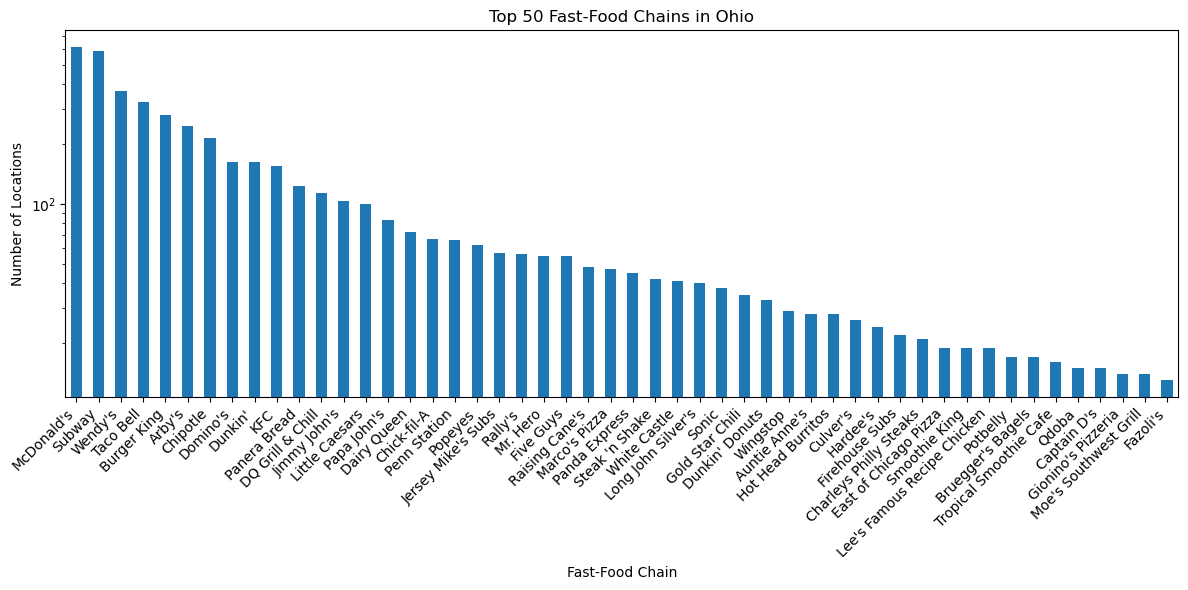

In [17]:
counts = fastfood["name"].value_counts().head(50)  
import matplotlib.pyplot as plt
# Plot
plt.figure(figsize=(12, 6))
counts.plot(kind="bar")
plt.title("Top 50 Fast-Food Chains in Ohio")
plt.ylabel("Number of Locations")
plt.xlabel("Fast-Food Chain")
plt.yscale("log")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

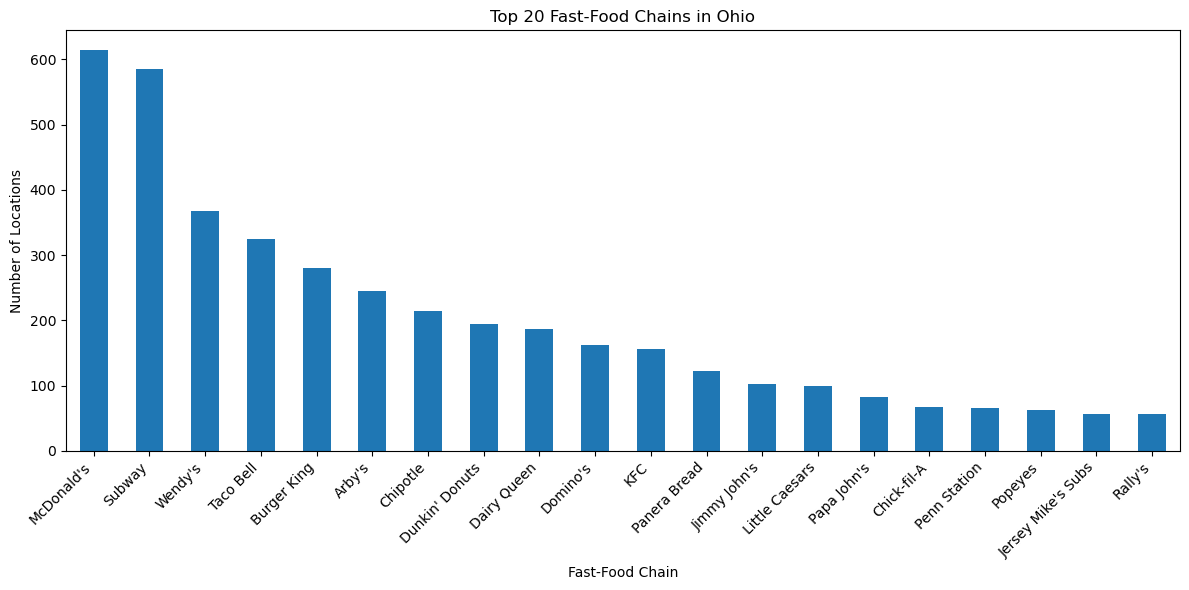

In [35]:
# dunkin' and dunkin' donuts is the same (recent rebranding),
# also DQ Grill and Chill and Dairy Queen are technically the same company
fastfood["name_normalized"] = fastfood["name"].replace({
    "Dunkin'": "Dunkin' Donuts",
    "Dunkin": "Dunkin' Donuts",
    "DQ Grill & Chill": "Dairy Queen"
})

counts = fastfood["name_normalized"].value_counts().head(20)

plt.figure(figsize=(12, 6))
counts.plot(kind="bar")
plt.title("Top 20 Fast-Food Chains in Ohio")
plt.ylabel("Number of Locations")
plt.xlabel("Fast-Food Chain")
#plt.yscale("log")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

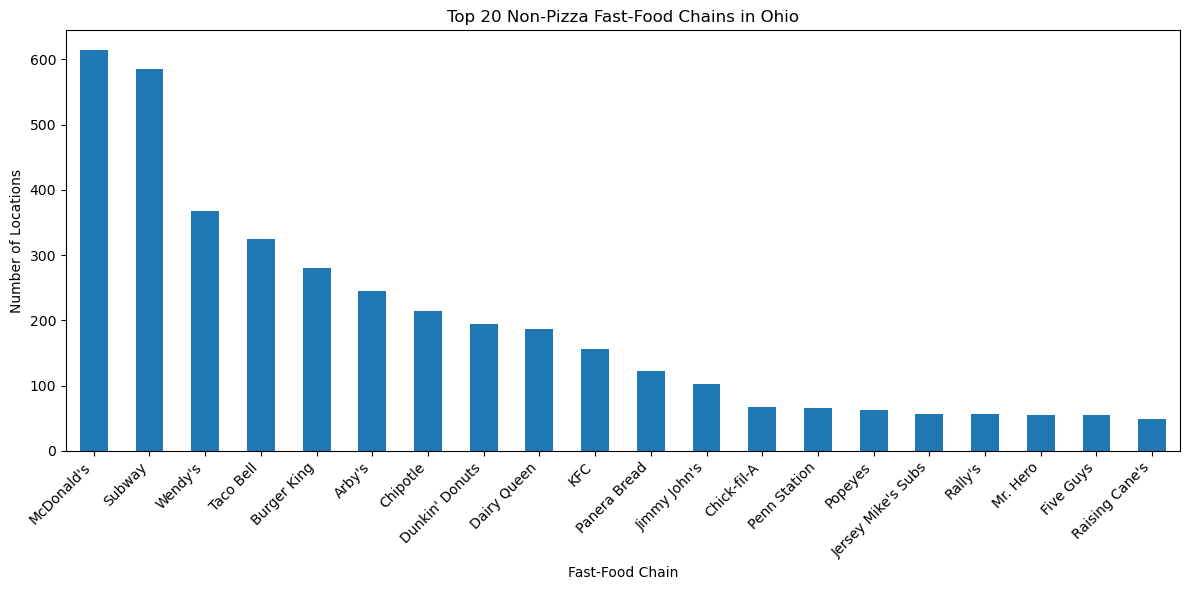

In [36]:
# List of pizza chains to exclude
pizza_chains = [
    "Domino's", "Papa John's", "Little Caesars", 
    "Marco's Pizza", "Donatos Pizza", "Imo's Pizza", "Mancino's", "Donatos"
]

# Filter out pizza chains
fastfood_non_pizza = fastfood[~fastfood["name_normalized"].isin(pizza_chains)]

# Count occurrences of each remaining chain
counts = fastfood_non_pizza["name_normalized"].value_counts().head(20)

# Plot
plt.figure(figsize=(12, 6))
counts.plot(kind="bar")
plt.title("Top 20 Non-Pizza Fast-Food Chains in Ohio")
plt.ylabel("Number of Locations")
plt.xlabel("Fast-Food Chain")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [37]:
print(fastfood_non_pizza["name_normalized"].value_counts().head(20))

name_normalized
McDonald's            614
Subway                585
Wendy's               368
Taco Bell             325
Burger King           281
Arby's                245
Chipotle              214
Dunkin' Donuts        195
Dairy Queen           186
KFC                   156
Panera Bread          123
Jimmy John's          103
Chick-fil-A            67
Penn Station           66
Popeyes                62
Jersey Mike's Subs     57
Rally's                56
Mr. Hero               55
Five Guys              55
Raising Cane's         48
Name: count, dtype: int64


In [38]:
# make a file with location only for the fast food places
# fastfood is a geodataframe already
# attention: the geometry column contains both points and polygons

selectcolumns = ["geometry", "name_normalized", "amenity"]
fastfood_locations = fastfood_non_pizza[selectcolumns]
fastfood_locations.to_file("Data/fastfood_location_name_amenity.gpkg", layer="fastfood_locations", driver="GPKG")

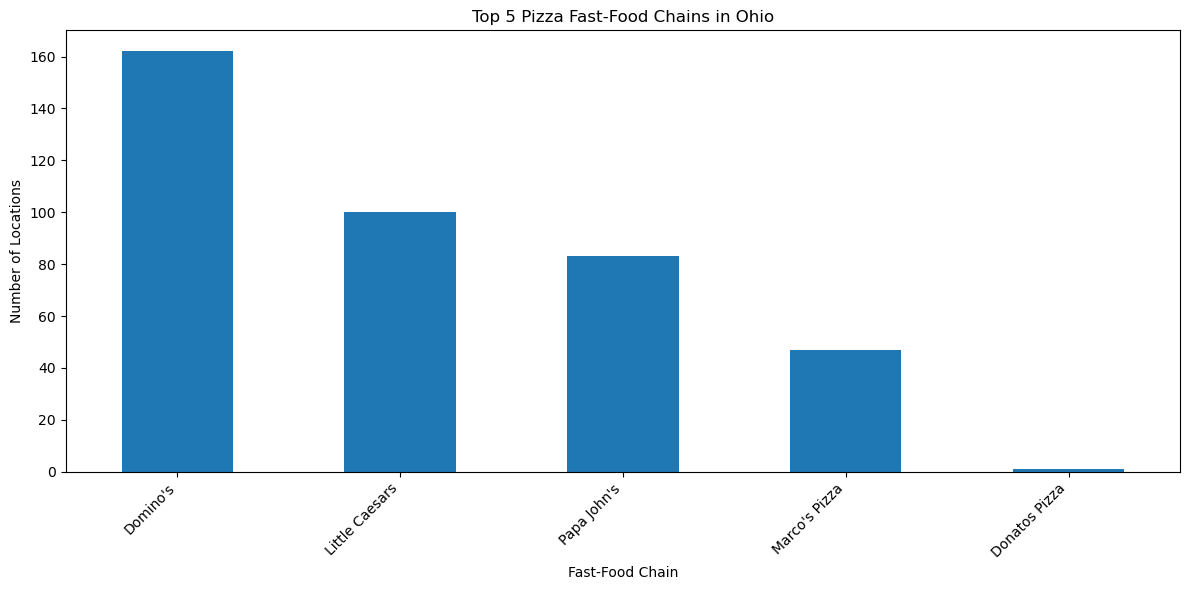

In [16]:
# Filter out pizza chains
fastfood_pizza = fastfood[fastfood["name_normalized"].isin(pizza_chains)]

# Count occurrences of each remaining chain
counts = fastfood_pizza["name_normalized"].value_counts().head(5)

# Plot
plt.figure(figsize=(12, 6))
counts.plot(kind="bar")
plt.title("Top 5 Pizza Fast-Food Chains in Ohio")
plt.ylabel("Number of Locations")
plt.xlabel("Fast-Food Chain")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

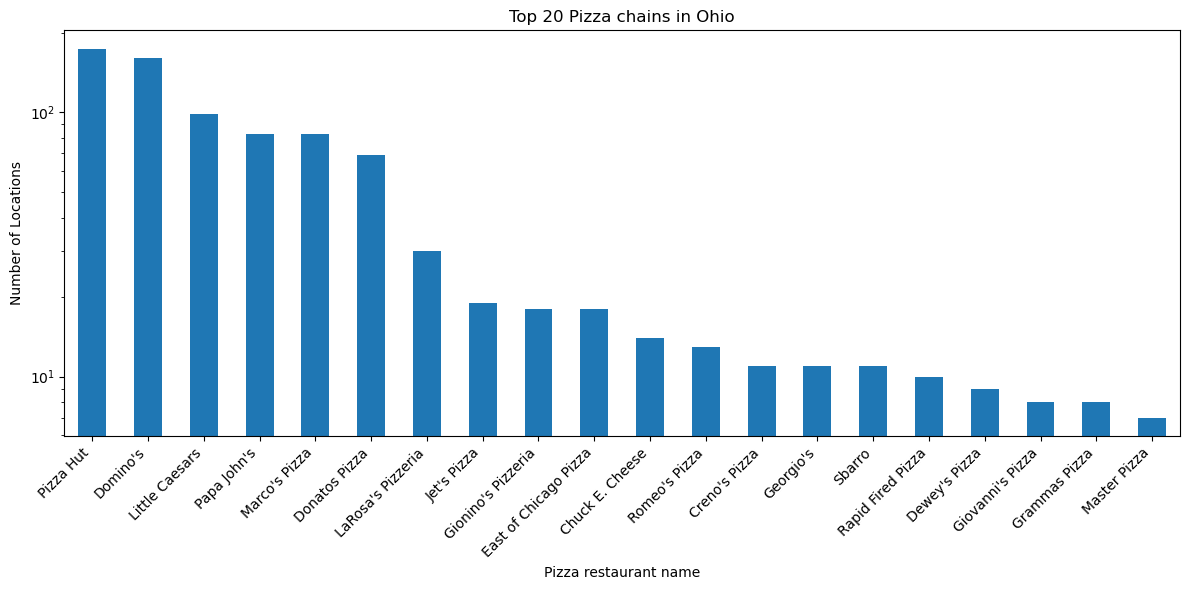

In [22]:
# from the pizza file, get the pizza place occurences

pizzacounts = pizza["name"].value_counts().head(20)

# Plot
plt.figure(figsize=(12, 6))
pizzacounts.plot(kind="bar")
plt.title("Top 20 Pizza chains in Ohio")
plt.ylabel("Number of Locations")
plt.xlabel("Pizza restaurant name")
plt.yscale("log")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [26]:
# merge all the different spelling options for Donatos Pizza to the most common one "Donatos Pizza" manually

pizza["name_normalized"] = pizza["name"].replace({
    "Donato's": "Donatos Pizza",
    "Donatos at Oxley's": "Donatos Pizza",
    "Donatoâ€™s Pizza": "Donatos Pizza",
    "Donatos Pizzeria": "Donatos Pizza"
})

# several chains have issues with spelling because of apostrophe, so make this more uniform:
pizza["name_merged"] = pizza["name"].apply(lambda x: "Donatos Pizza" if "donato" in str(x).lower() else x)
pizza["name_merged"] = pizza["name"].apply(lambda x: "Angelos Pizza" if "angelo" in str(x).lower() else x)
pizza["name_merged"] = pizza["name"].apply(lambda x: "Beer Barrel" if "beer barrel" in str(x).lower() else x)
pizza["name_merged"] = pizza["name"].apply(lambda x: "Chuck E. Cheese" if "chuck e." in str(x).lower() else x)
pizza["name_merged"] = pizza["name"].apply(lambda x: "Domino's" if "domino" in str(x).lower() else x)
pizza["name_merged"] = pizza["name"].apply(lambda x: "Dough Boyz Pizza" if 'dough boyz' in str(x).lower() else x)
pizza["name_merged"] = pizza["name"].apply(lambda x: "Flyers Pizza" if "flyer" in str(x).lower() else x)
pizza["name_merged"] = pizza["name"].apply(lambda x: "Georigo's Pizza" if "georgio" in str(x).lower() else x)
pizza["name_merged"] = pizza["name"].apply(lambda x: "Gionino's Pizza" if "gionino" in str(x).lower() else x)
pizza["name_merged"] = pizza["name"].apply(lambda x: "Giordano's Pizza" if "giordano" in str(x).lower() else x)
pizza["name_merged"] = pizza["name"].apply(lambda x: "Giovanni's Pizza" if "giovanni" in str(x).lower() else x)
pizza["name_merged"] = pizza["name"].apply(lambda x: "Grandma's Pizza" if "grandma" in str(x).lower() else x)
pizza["name_merged"] = pizza["name"].apply(lambda x: "Hungy Howie's" if "hungy howie" in str(x).lower() else x)
pizza["name_merged"] = pizza["name"].apply(lambda x: "LaRosa's Pizzeria" if "larosa" in str(x).lower() else x)
pizza["name_merged"] = pizza["name"].apply(lambda x: "Little Ceasars" if "little ceasar" in str(x).lower() else x)
pizza["name_merged"] = pizza["name"].apply(lambda x: "Marco's Pizza" if "marco" in str(x).lower() else x)
pizza["name_merged"] = pizza["name"].apply(lambda x: "Mio's Pizzeria" if "mio" in str(x).lower() else x)
pizza["name_merged"] = pizza["name"].apply(lambda x: "Flyers Pizza" if "flyer" in str(x).lower() else x)
pizza["name_merged"] = pizza["name"].apply(lambda x: "Papa John's" if "papa john" in str(x).lower() else x)

pizza_counts = pizza["name_merged"].value_counts().head(20)
print(pizza_counts)

name_merged
Pizza Hut                174
Domino's                 161
Little Caesars            99
Papa John's               84
Marco's Pizza             83
Donatos Pizza             69
LaRosa's Pizzeria         30
Jet's Pizza               19
East of Chicago Pizza     18
Gionino's Pizzeria        18
Chuck E. Cheese           14
Romeo's Pizza             13
Creno's Pizza             11
Georgio's                 11
Sbarro                    11
Rapid Fired Pizza         10
Dewey's Pizza              9
Grammas Pizza              8
Giovanni's Pizza           8
Master Pizza               7
Name: count, dtype: int64


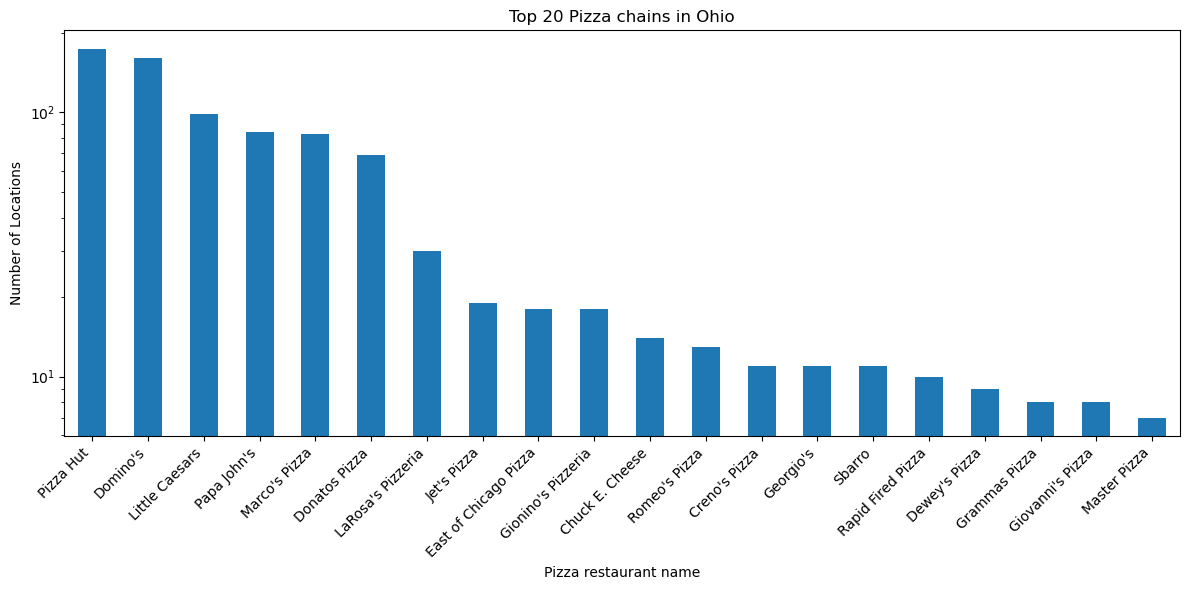

In [27]:
# After merging the names, do another plot of the most common pizza chains

pizzacounts = pizza["name_merged"].value_counts().head(20)

# Plot
plt.figure(figsize=(12, 6))
pizzacounts.plot(kind="bar")
plt.title("Top 20 Pizza chains in Ohio")
plt.ylabel("Number of Locations")
plt.xlabel("Pizza restaurant name")
plt.yscale("log")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [29]:
# make a file that contains the locations of the pizza places
# pizza is a geodataframe already
# attention: the geometry column contains both points and polygons

selectedcolumns = ["geometry", "name_merged", "cuisine"]
pizza_locations = pizza[selectedcolumns]
pizza_locations.to_file("Data/pizza_location_name_cuisine.gpkg", layer="pizza_locations", driver="GPKG")